# PERGUNTA 4

# Comparativo entre cargos.

Importando as Blibliotecas **pandas, numpy e matplotlib.pylot**

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Criando **FUNÇÃO** para carregar um arquivo **csv**

In [64]:
def carregar_banco_csv(caminho):
    return pd.read_csv(caminho)
    pass

Puxando a **FUNÇÃO** através da **VARIÁVEL**, e retornando o **BANCO DE DADOS**

In [65]:
df = carregar_banco_csv(
    r"C:\Users\User\Desktop\BECKUP - PALMEIRAS\CAIXAVERSO - ADA\AULAS PRESENCIAIS\4 - TECNICAS DE PROGRAMAÇÃO I (PY) - DE 12-05-2026 A 26-05-2026\PROJETO\salario_ciencia_dados.csv"
)
df.head()

,cargo,nivel_experiencia,tipo_contrato,modalidade,ano,pais_residencia,salario_moeda_corrente,moeda_corrente,salario_usd,pais_empresa,porte_empresa
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium


# Comparem Data Analyst, Data Scientist, Data Engineer e Machine Learning Engineer (ou similares no dataset): qual paga mais, qual tem mais vagas, qual tem maior crescimento ao longo dos anos?

**Qual cargo paga mais, na média**

In [66]:
# Média salarial geral
media_geral = round(df["salario_usd"].mean(), 2)
print(f"Média salarial geral de todos os funcionários: U$ {media_geral}\n")
# Filtrar apenas os cargos principais
cargos_principais = ["Data Analyst", "Data Scientist", "Data Engineer","Machine Learning Engineer"]
df_filtrado = df[df["cargo"].isin(cargos_principais)]
# Média salarial por nível de experiência
salario_por_cargo = df_filtrado.groupby("cargo")["salario_usd"].mean().round(2).sort_values()
print(salario_por_cargo)

Média salarial geral de todos os funcionários: U$ 145560.56

cargo
Data Analyst                 106931.69
Data Engineer                144539.70
Data Scientist               149036.65
Machine Learning Engineer    177226.45
Name: salario_usd, dtype: float64


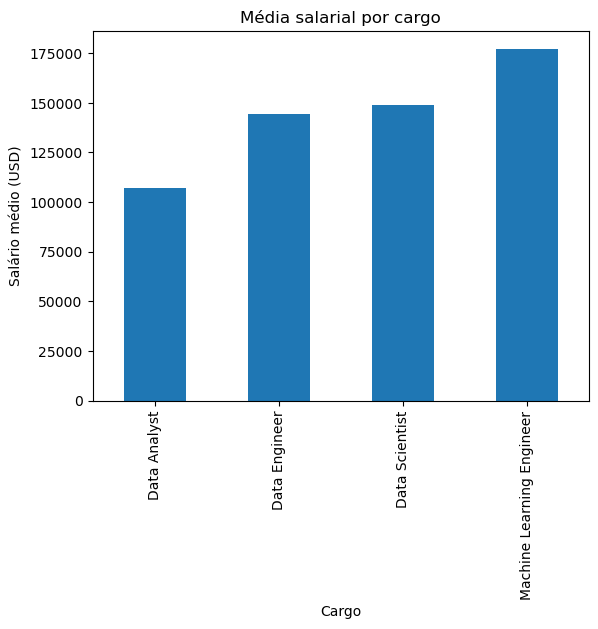

In [67]:
salario_por_cargo.T.plot(kind="bar")
plt.title("Média salarial por cargo")
plt.ylabel("Salário médio (USD)")
plt.xlabel("Cargo")
plt.show()

**Qual cargo tem mais Funcionários?**

In [68]:
# Contagem de funcionários por cargo
contagem_cargos = df_filtrado["cargo"].value_counts()
# Pegar os cargos específicos
d_a = contagem_cargos.get("Data Analyst", 0)
d_e = contagem_cargos.get("Data Engineer", 0)
d_s = contagem_cargos.get("Data Scientist", 0)
m_l_e = contagem_cargos.get("Machine Learning Engineer", 0)
# Impressão otimizada
print(f"Os cargos abaixo têm um total de {d_a + d_e + d_s + m_l_e} funcionários ao todo\n")
print(f"O cargo de Analista de Dados tem {d_a} funcionários")
print(f"O cargo de Engenheiro de Dados tem {d_e} funcionários")
print(f"O cargo de Cientista de Dados tem {d_s} funcionários")
print(f"O cargo de Engenheiro de Aprendizado de Máquina tem {m_l_e} funcionários")

Os cargos abaixo têm um total de 4089 funcionários ao todo

O cargo de Analista de Dados tem 910 funcionários
O cargo de Engenheiro de Dados tem 1307 funcionários
O cargo de Cientista de Dados tem 1243 funcionários
O cargo de Engenheiro de Aprendizado de Máquina tem 629 funcionários


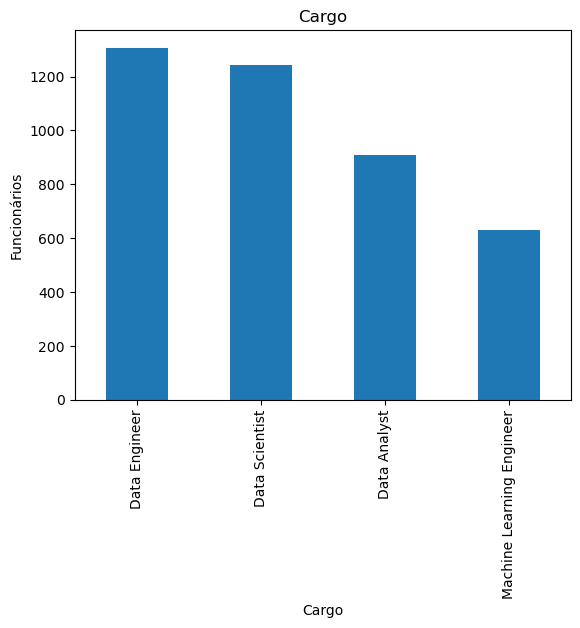

In [69]:
contagem_cargos.T.plot(kind="bar")
plt.title("Cargo")
plt.ylabel("Funcionários")
plt.xlabel("Cargo")
plt.show()

**Qual cargo tem maior crescimento, tanto em Vagas como Salário, ao longo dos anos?**

In [70]:
anos = sorted(df_filtrado["ano"].unique(), reverse=False)
for ano in anos:
    print(f"\nANO {ano}")
    # Filtrar apenas os dados do ano atual
    df_ano = df_filtrado[df_filtrado["ano"] == ano]
    # Contagem de cargos nesse ano
    contagem_cargos = df_ano["cargo"].value_counts()
    d_a = contagem_cargos.get("Data Analyst", 0)
    d_e = contagem_cargos.get("Data Engineer", 0)
    d_s = contagem_cargos.get("Data Scientist", 0)
    m_l_e = contagem_cargos.get("Machine Learning Engineer", 0)
    s_cargos = d_a + d_e + d_s + m_l_e
    # Média salarial do cargo Data Analyst nesse ano
    sal_d_a = df_ano[df_ano["cargo"] == "Data Analyst"]["salario_usd"].mean().round(2)
    sal_d_e = df_ano[df_ano["cargo"] == "Data Engineer"]["salario_usd"].mean().round(2)
    sal_d_s = df_ano[df_ano["cargo"] == "Data Scientist"]["salario_usd"].mean().round(2)
    sal_m_l_e = df_ano[df_ano["cargo"] == "Machine Learning Engineer"]["salario_usd"].mean().round(2)
    m_sal = (((sal_d_a*d_a) + (sal_d_e*d_e) + (sal_d_s*d_s) + (sal_m_l_e*m_l_e)) / s_cargos).round(2)
    print(f"Os cargos abaixo têm um total de {s_cargos} funcionários ao todo e a média salarial é: {m_sal}")
    print(f"O cargo de Analista de Dados tem {d_a} funcionários e a média salarial é: U$ {sal_d_a}")
    print(f"O cargo de Engenheiro de Dados tem {d_e} funcionários e a média salarial é: U$ {sal_d_e}")
    print(f"O cargo de Cientista de Dados tem {d_s} funcionários e a média salarial é: U$ {sal_d_s}")
    print(f"O cargo de Engenheiro de Aprendizado de Máquina tem {m_l_e} funcionários e a média salarial é: U$ {sal_m_l_e}")



ANO 2020
Os cargos abaixo têm um total de 44 funcionários ao todo e a média salarial é: 87804.18
O cargo de Analista de Dados tem 6 funcionários e a média salarial é: U$ 60911.17
O cargo de Engenheiro de Dados tem 13 funcionários e a média salarial é: U$ 85301.38
O cargo de Cientista de Dados tem 21 funcionários e a média salarial é: U$ 85970.52
O cargo de Engenheiro de Aprendizado de Máquina tem 4 funcionários e a média salarial é: U$ 145904.5

ANO 2021
Os cargos abaixo têm um total de 113 funcionários ao todo e a média salarial é: 82838.49
O cargo de Analista de Dados tem 20 funcionários e a média salarial é: U$ 78258.5
O cargo de Engenheiro de Dados tem 36 funcionários e a média salarial é: U$ 93258.17
O cargo de Cientista de Dados tem 39 funcionários e a média salarial é: U$ 79366.23
O cargo de Engenheiro de Aprendizado de Máquina tem 18 funcionários e a média salarial é: U$ 74611.22

ANO 2022
Os cargos abaixo têm um total de 776 funcionários ao todo e a média salarial é: 129070.2

In [71]:
anos = sorted(df_filtrado["ano"].unique(), reverse=False)
# Lista para armazenar os resultados
resultados = []
for ano in anos:
    # Filtrar apenas os dados do ano atual
    df_ano = df_filtrado[df_filtrado["ano"] == ano]
    # Contagem de cargos nesse ano
    contagem_cargos = df_ano["cargo"].value_counts()
    d_a = contagem_cargos.get("Data Analyst", 0)
    d_e = contagem_cargos.get("Data Engineer", 0)
    d_s = contagem_cargos.get("Data Scientist", 0)
    m_l_e = contagem_cargos.get("Machine Learning Engineer", 0)
    s_cargos = d_a + d_e + d_s + m_l_e
    # Médias salariais por cargo nesse ano
    sal_d_a = df_ano[df_ano["cargo"] == "Data Analyst"]["salario_usd"].mean().round(2)
    sal_d_e = df_ano[df_ano["cargo"] == "Data Engineer"]["salario_usd"].mean().round(2)
    sal_d_s = df_ano[df_ano["cargo"] == "Data Scientist"]["salario_usd"].mean().round(2)
    sal_m_l_e = df_ano[df_ano["cargo"] == "Machine Learning Engineer"]["salario_usd"].mean().round(2)
    # Média ponderada geral dos cargos
    m_sal = (((sal_d_a*d_a) + (sal_d_e*d_e) + (sal_d_s*d_s) + (sal_m_l_e*m_l_e)) / s_cargos).round(2) if s_cargos > 0 else 0
    # Adicionar ao resultado
    resultados.append({
        "Ano": ano,
        "Total Funcionários": s_cargos,
        "Média Salarial Geral": m_sal,
        "Data Analyst (Qtd)": d_a,
        "Data Analyst (Média)": sal_d_a,
        "Data Engineer (Qtd)": d_e,
        "Data Engineer (Média)": sal_d_e,
        "Data Scientist (Qtd)": d_s,
        "Data Scientist (Média)": sal_d_s,
        "ML Engineer (Qtd)": m_l_e,
        "ML Engineer (Média)": sal_m_l_e
    })
# Converter em DataFrame
tabela_resultados = pd.DataFrame(resultados)
print(tabela_resultados)

    Ano  Total Funcionários  Média Salarial Geral  Data Analyst (Qtd)  \
0  2020                  44              87804.18                   6   
1  2021                 113              82838.49                  20   
2  2022                 776             129070.22                 168   
3  2023                2799             148962.19                 638   
4  2024                 357             147398.94                  78   

   Data Analyst (Média)  Data Engineer (Qtd)  Data Engineer (Média)  \
0              60911.17                   13               85301.38   
1              78258.50                   36               93258.17   
2             105140.04                  278              138287.87   
3             108840.54                  874              148982.56   
4             106069.36                  106              148984.81   

   Data Scientist (Qtd)  Data Scientist (Média)  ML Engineer (Qtd)  \
0                    21                85970.52                 

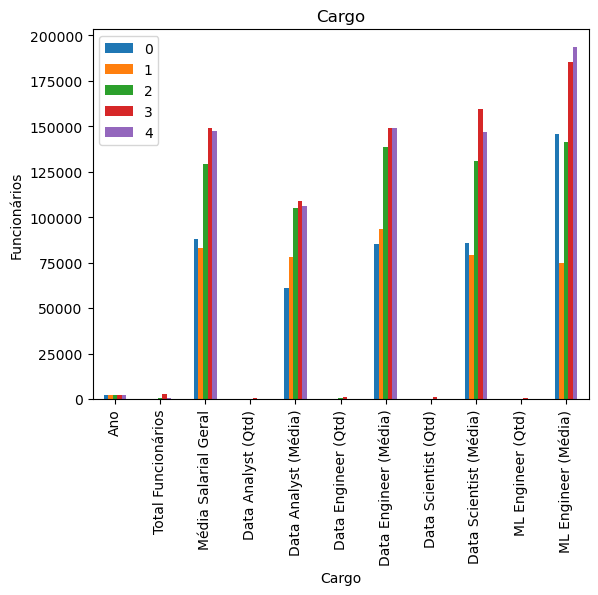

In [72]:
tabela_resultados.T.plot(kind="bar")
plt.title("Cargo")
plt.ylabel("Funcionários")
plt.xlabel("Cargo")
plt.show()